# Legendre truncation

#### Import general modules

mpi4py is always required when using these tools. Numpy is always good to have if any manipulation is to be done.

In [1]:
# Import required modules
from mpi4py import MPI #equivalent to the use of MPI_init() in C
import matplotlib.pyplot as plt
import numpy as np

# Get mpi info
comm = MPI.COMM_WORLD

import os
os.environ["PYSEMTOOLS_DEBUG"] = 'false'
os.environ["PYSEMTOOLS_HIDE_LOG"] = 'false'

def get_folder_size(folder):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(folder):
        for filename in filenames:
            file_path = os.path.join(dirpath, filename)
            total_size += os.path.getsize(file_path)
    return total_size

#### Import modules from pysemtools

In this case we will import all the data types that we currently support, as well as io functions that are required to populate them.

In [2]:
# Data types
from pysemtools.datatypes.msh import Mesh
from pysemtools.datatypes.coef import Coef
from pysemtools.datatypes.field import Field, FieldRegistry

# Readers
from pysemtools.io.ppymech.neksuite import preadnek, pynekread

# Writers
from pysemtools.io.ppymech.neksuite import pwritenek, pynekwrite

fname = '../../data/mixlay0.f00001'

## Read the data

In [3]:
# Read the data
msh = Mesh(comm, create_connectivity=False)
fld = FieldRegistry(comm)
pynekread(fname, comm, data_dtype=np.single, msh = msh, fld = fld)
pynekwrite("test_no_mesh", comm, msh = msh, fld = fld, write_mesh=False)
 
# Get the coefficients
coef = Coef(msh=msh, comm=comm)

2026-08-06 13:44:29,822  pynekread             INFO      Reading file: ../../data/mixlay0.f00001
2026-08-06 13:44:29,834  Mesh                  INFO      Mesh object initialized from coordinates with type: float32 - Elapsed time: 0.0061096100000000006s
2026-08-06 13:44:29,838  Field                 INFO      Field registry updated with: ['u', 'v', 'p', 't', 's0', 's1'] - dtype: float32
2026-08-06 13:44:29,839  pynekread             INFO      File successfully read - Elapsed time: 0.016723205s
2026-08-06 13:44:29,839  pynekwrite            INFO      Writing file: test_no_mesh
2026-08-06 13:44:29,842  pynekwrite            INFO      File written - Elapsed time: 0.002808414000000002s
2026-08-06 13:44:29,848  Coef                  INFO      Coef object initialized - dtype: float32 - Elapsed time: 0.005294053s


## Compress the data with GPR

### Initialize the Direct sampler

In [4]:
from pysemtools.compression.legendre_truncation import DiscreetLegendreTruncation
from pysemtools.compression.legendre_truncation_bitplane import DiscreetLegendreTruncationBP
from pysemtools.compression.legendre_truncation_bitplaneV2 import DiscreetLegendreTruncationBPAdaptive
from pysemtools.compression.zfp_wrapper import ZFPWrapper

# Initialize all samplers with numpy backend
dlt = DiscreetLegendreTruncation(comm=comm, msh=msh, coef=coef)
dlt_bp = DiscreetLegendreTruncationBP(comm=comm, msh=msh, coef=coef)
dlt_bp_v2 = DiscreetLegendreTruncationBPAdaptive(comm=comm, msh=msh, coef=coef)
dlt_zfp = ZFPWrapper(comm=comm, msh=msh)

2026-08-06 13:44:31,142  DirectSampler         INFO      Initializing the DirectSampler from a Mesh object
2026-08-06 13:44:31,147  DirectSampler         INFO      Initializing the DirectSampler from a Mesh object
2026-08-06 13:44:31,151  DirectSampler         INFO      Initializing the DirectSampler from a Mesh object
2026-08-06 13:44:31,157  DirectSampler         INFO      Initializing the DirectSampler from a Mesh object


### Sample the data

In [5]:
# Select the options
target_error = 1e-6
zfp_bitrate_percent_levels = [i / 100 for i in range(1, 100)]
field_names = list(fld.registry.keys())

for fld_name in field_names:

    # Existing fixed-error type
    dlt.log.tic()
    dlt.sample_field(field=fld.registry[fld_name], field_name=fld_name, compression_method="fixed_error", target_error=target_error)
    dlt.log.toc()

    # Bitplane V1
    dlt_bp.log.tic()
    dlt_bp.sample_field(field=fld.registry[fld_name], field_name=fld_name, target_error=target_error)
    dlt_bp.log.toc()

    # Bitplane V2 (adaptive)
    dlt_bp_v2.log.tic()
    dlt_bp_v2.sample_field(field=fld.registry[fld_name], field_name=fld_name, target_error=target_error)
    dlt_bp_v2.log.toc()

    # ZFP is handled in a dedicated bitrate sweep cell below (compress+decompress+selection).

2026-08-06 13:44:31,173  DirectSampler         INFO      Sampling the field with options: covariance_method: {covariance_method}, compression_method: {compression_method}
2026-08-06 13:44:31,174  DirectSampler         INFO      Transforming the field into to legendre space
2026-08-06 13:44:31,178  DirectSampler         INFO      Sampling the field using the fixed error method. using settings: {'method': 'fixed_error', 'target_error': 1e-06, 'max_samples_per_it': 1}
2026-08-06 13:44:31,185  DirectSampler         INFO      Sampled_field saved in field uncompressed_data["u"]["field"]
2026-08-06 13:44:31,186  DirectSampler         INFO      Elapsed time: 0.01310143599999991s
2026-08-06 13:44:31,189  DirectSampler         INFO      Sampling field "u" with target_error=1e-06
2026-08-06 13:44:31,190  DirectSampler         INFO      Transforming the field into to legendre space
2026-08-06 13:44:31,197  DirectSampler         INFO      Sampling the field using bitplane coding. using settings: {'

### Encode it

In [6]:
dlt.compress_samples(lossless_compressor="bzip2")
dlt_bp.compress_samples(lossless_compressor="bzip2")
dlt_bp_v2.compress_samples(lossless_compressor="bzip2")

2026-08-06 13:44:49,259  DirectSampler         INFO      Compressing the data using the lossless compressor: bzip2
2026-08-06 13:44:49,260  DirectSampler         INFO      Compressing data in uncompressed_data
2026-08-06 13:44:49,261  DirectSampler         INFO      Compressing data for field ["u"]:
2026-08-06 13:44:49,261  DirectSampler         INFO      Compressing ["field"] for field ["u"]
2026-08-06 13:44:49,321  DirectSampler         INFO      Compressing data for field ["v"]:
2026-08-06 13:44:49,321  DirectSampler         INFO      Compressing ["field"] for field ["v"]
2026-08-06 13:44:49,374  DirectSampler         INFO      Compressing data for field ["p"]:
2026-08-06 13:44:49,375  DirectSampler         INFO      Compressing ["field"] for field ["p"]
2026-08-06 13:44:49,402  DirectSampler         INFO      Compressing data for field ["t"]:
2026-08-06 13:44:49,403  DirectSampler         INFO      Compressing ["field"] for field ["t"]
2026-08-06 13:44:49,432  DirectSampler        

### Write it out

In [7]:
# ZFP fixed-bitrate sweep on the first field only: select the first bitrate that meets target_error
# using the same physical-space B-weighted mean RMS metric used in this notebook.
zfp_selected = {}
dlt_zfp = ZFPWrapper(comm=comm, msh=msh)
B = coef.B
den_B = np.sum(B, axis=(1, 2, 3))

first_fld_name = field_names[0]
u_first = fld.registry[first_fld_name]

# Use the actual source dtype for bitrate scaling (e.g., 32 for float32 fields).
dtype_bits = u_first.dtype.itemsize * 8
print(f"[{first_fld_name}] dtype={u_first.dtype}, dtype_bits={dtype_bits}")

zfp_sweep_results = []
zfp_selected_bitrate = None
zfp_selected_error = None
zfp_selected_percent = None

for pct in zfp_bitrate_percent_levels:
    bitrate = pct * dtype_bits

    zfp_trial = ZFPWrapper(comm=comm, msh=msh)
    zfp_trial.sample_field(
        field=u_first,
        field_name=first_fld_name,
        compression_method="fixed_bitrate",
        bitrate=bitrate,
    )
    zfp_trial.compress_samples()

    trial_data = zfp_trial.decompress_samples(zfp_trial.settings, zfp_trial.compressed_data)
    if first_fld_name not in trial_data:
        raise KeyError(f"ZFP trial reconstruction missing field '{first_fld_name}'.")
    u_trial = trial_data[first_fld_name]["field"]

    err_trial = u_trial - u_first
    num_B_trial = np.sum((err_trial**2) * B, axis=(1, 2, 3))
    mean_weighted_rms_trial = np.mean(np.sqrt(num_B_trial / den_B))
    zfp_sweep_results.append((pct, bitrate, mean_weighted_rms_trial))

    print(
        f"[{first_fld_name}] zfp level={pct:.0%}, rate={bitrate:.2f} bits/value, "
        f"mean B-weighted RMS={mean_weighted_rms_trial:.3e}"
    )

    if mean_weighted_rms_trial <= target_error:
        zfp_selected_bitrate = bitrate
        zfp_selected_error = mean_weighted_rms_trial
        zfp_selected_percent = pct
        break

if zfp_selected_bitrate is None:
    raise RuntimeError(
        f"No ZFP percentage level met target_error for field '{first_fld_name}'. "
        "Expand zfp_bitrate_percent_levels or relax target_error."
    )

# Keep the selected ZFP bitrate global and reuse it for every field.
zfp_selected = {
    "reference_field": first_fld_name,
    "bitrate": zfp_selected_bitrate,
    "percent": zfp_selected_percent,
    "error": zfp_selected_error,
    "dtype_bits": dtype_bits,
    "sweep": zfp_sweep_results,
}

# Apply the selected ZFP bitrate to all fields and add them to the final multi-field ZFP object.
for fld_name in field_names:
    u = fld.registry[fld_name]

    dlt_zfp.sample_field(
        field=u,
        field_name=fld_name,
        compression_method="fixed_bitrate",
        bitrate=zfp_selected["bitrate"],
    )

    print(
        f"[{fld_name}] Reusing ZFP level={zfp_selected['percent']:.0%}, "
        f"rate={zfp_selected['bitrate']:.2f} bits/value, "
        f"mean B-weighted RMS={zfp_selected['error']:.3e}"
    )

# Write only the selected ZFP case to disk for fair file-size comparison.
dlt_zfp.compress_samples()

# Avoid stale output artifacts from previous runs when comparing folder sizes.
for out_name in ["test", "test_bp", "test_bp_v2", "test_zfp"]:
    comp_folder = f"{out_name}_comp"
    if os.path.isdir(comp_folder):
        for fname_local in os.listdir(comp_folder):
            os.remove(os.path.join(comp_folder, fname_local))
    if os.path.isfile(out_name):
        os.remove(out_name)

dlt.write_compressed_samples(comm=comm, filename="test")
dlt_bp.write_compressed_samples(comm=comm, filename="test_bp")
dlt_bp_v2.write_compressed_samples(comm=comm, filename="test_bp_v2")
dlt_zfp.write_compressed_samples(comm=comm, filename="test_zfp")

2026-08-06 13:44:50,230  DirectSampler         INFO      Initializing the DirectSampler from a Mesh object
[u] dtype=float32, dtype_bits=32
2026-08-06 13:44:50,237  DirectSampler         INFO      Initializing the DirectSampler from a Mesh object
2026-08-06 13:44:50,241  DirectSampler         INFO      Compressing data in uncompressed_data
2026-08-06 13:44:50,242  DirectSampler         INFO      Compressing data for field ["u"]:
2026-08-06 13:44:50,243  DirectSampler         INFO      Compressing ["field"] for field ["u"]
[u] zfp level=1%, rate=0.32 bits/value, mean B-weighted RMS=1.533e-02
2026-08-06 13:44:50,248  DirectSampler         INFO      Initializing the DirectSampler from a Mesh object
2026-08-06 13:44:50,251  DirectSampler         INFO      Compressing data in uncompressed_data
2026-08-06 13:44:50,252  DirectSampler         INFO      Compressing data for field ["u"]:
2026-08-06 13:44:50,252  DirectSampler         INFO      Compressing ["field"] for field ["u"]
[u] zfp level=

## Decompress the data

### Read the data

In [8]:
dlt_read = DiscreetLegendreTruncation(comm, filename="test")
dlt_bp_read = DiscreetLegendreTruncationBP(comm, filename="test_bp")
dlt_bp_v2_read = DiscreetLegendreTruncationBPAdaptive(comm, filename="test_bp_v2")
dlt_zfp_read = ZFPWrapper(comm, filename="test_zfp")

2026-08-06 13:44:51,054  DirectSampler         INFO      Initializing the DirectSampler from file: test
2026-08-06 13:44:51,164  DirectSampler         INFO      Initializing the DirectSampler from file: test_bp
2026-08-06 13:44:51,282  DirectSampler         INFO      Initializing the DirectSampler from file: test_bp_v2
2026-08-06 13:44:51,396  DirectSampler         INFO      Initializing the DirectSampler from file: test_zfp


### Reconstruct the data from the samples

In [9]:
# Recreate fresh readers from files to ensure reconstruction is strictly file-backed
dlt_read = DiscreetLegendreTruncation(comm, filename="test")
dlt_bp_read = DiscreetLegendreTruncationBP(comm, filename="test_bp")
dlt_bp_v2_read = DiscreetLegendreTruncationBPAdaptive(comm, filename="test_bp_v2")
dlt_zfp_read = ZFPWrapper(comm, filename="test_zfp")

u_np = {}
u_bp = {}
u_bp_v2 = {}
u_zfp = {}

for fld_name in field_names:
    u_np[fld_name] = dlt_read.reconstruct_field(field_name=fld_name)
    u_bp[fld_name] = dlt_bp_read.reconstruct_field(field_name=fld_name)
    u_bp_v2[fld_name] = dlt_bp_v2_read.reconstruct_field(field_name=fld_name)
    u_zfp[fld_name] = dlt_zfp_read.reconstruct_field(field_name=fld_name)

    if u_np[fld_name] is None or u_bp[fld_name] is None or u_bp_v2[fld_name] is None or u_zfp[fld_name] is None:
        raise RuntimeError(f"Reconstruction returned None for field '{fld_name}'.")

2026-08-06 13:44:51,486  DirectSampler         INFO      Initializing the DirectSampler from file: test
2026-08-06 13:44:51,596  DirectSampler         INFO      Initializing the DirectSampler from file: test_bp
2026-08-06 13:44:51,738  DirectSampler         INFO      Initializing the DirectSampler from file: test_bp_v2
2026-08-06 13:44:51,856  DirectSampler         INFO      Initializing the DirectSampler from file: test_zfp


## Additional checks: bitplane payload and metrics

## Visualize the data

In [10]:
# General settings
plot_fields = ["u", "v"] #list(field_names)
u_levels_by_field = {}
err_levels_by_field = {}

for fld_name in plot_fields:
    u = fld.registry[fld_name]
    u_levels_by_field[fld_name] = np.linspace(np.min(u), np.max(u), 100)

    err_fixed = np.abs(u_np[fld_name] - u)
    err_bp = np.abs(u_bp[fld_name] - u)
    err_bp_v2 = np.abs(u_bp_v2[fld_name] - u)
    err_zfp = np.abs(u_zfp[fld_name] - u)
    err_max = np.max([np.max(err_fixed), np.max(err_bp), np.max(err_bp_v2), np.max(err_zfp)])

    if err_max <= 0:
        err_max = 1e-15

    err_levels_by_field[fld_name] = 100

### Numpy

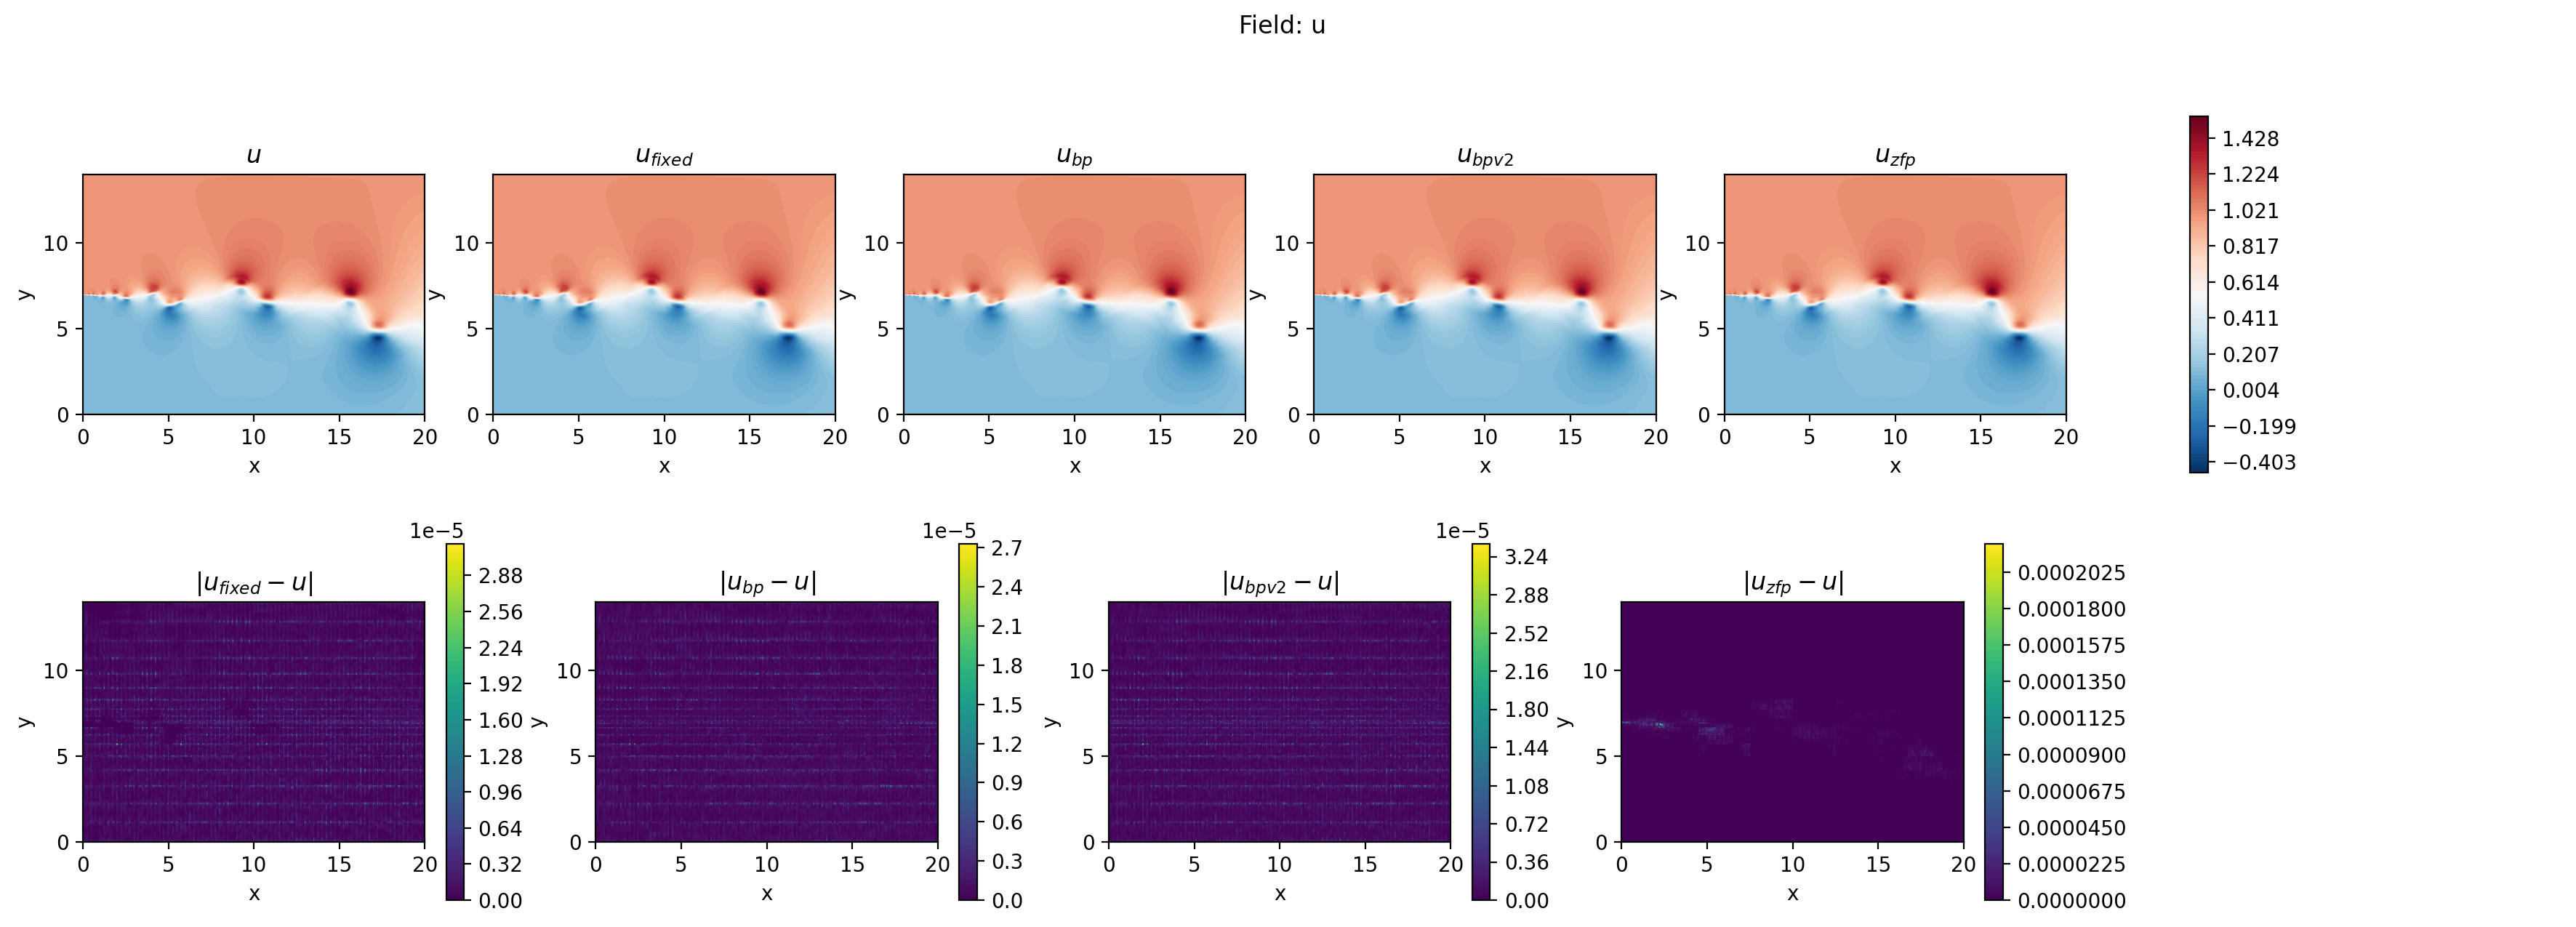

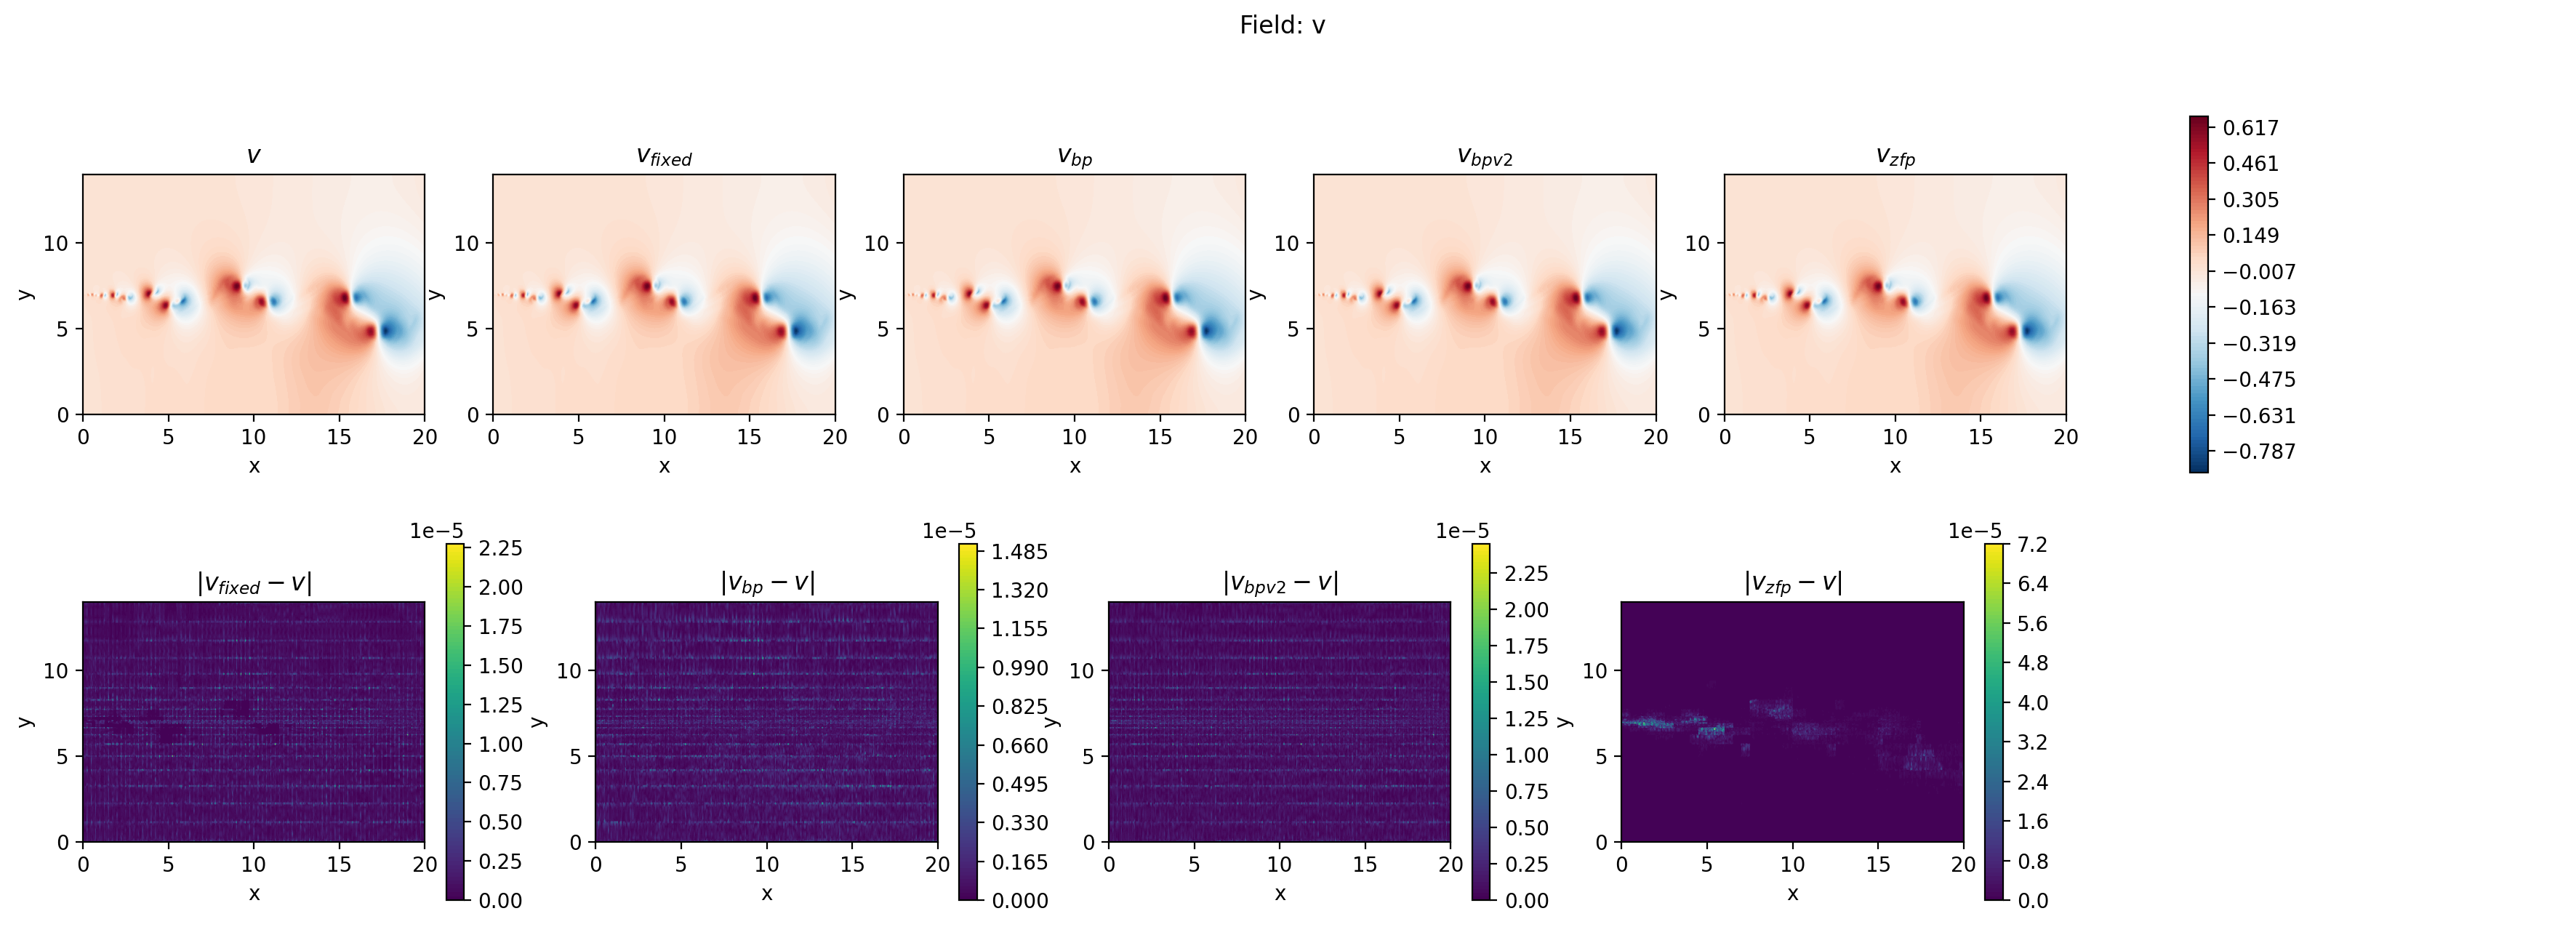

In [11]:
for fld_name in plot_fields:
    u = fld.registry[fld_name]
    u_ref = u_np[fld_name]
    u_bitplane = u_bp[fld_name]
    u_bitplane_v2 = u_bp_v2[fld_name]
    u_zfp_field = u_zfp[fld_name]

    u_levels = u_levels_by_field[fld_name]

    err_fixed = np.abs(u_ref - u)
    err_bp = np.abs(u_bitplane - u)
    err_bp_v2 = np.abs(u_bitplane_v2 - u)
    err_zfp = np.abs(u_zfp_field - u)

    fig, ax = plt.subplots(ncols=5, nrows=2, figsize=(22, 7), dpi=200)

    # Top row: original + reconstructions
    c00 = ax[0,0].tricontourf(msh.x.flatten(), msh.y.flatten(), u.flatten(), levels=u_levels, cmap="RdBu_r")
    ax[0,0].set_aspect('equal')
    ax[0,0].set_xlabel("x")
    ax[0,0].set_ylabel("y")
    ax[0,0].set_title(rf"${fld_name}$")

    c01 = ax[0,1].tricontourf(msh.x.flatten(), msh.y.flatten(), u_ref.flatten(), levels=u_levels, cmap="RdBu_r")
    ax[0,1].set_aspect('equal')
    ax[0,1].set_xlabel("x")
    ax[0,1].set_ylabel("y")
    ax[0,1].set_title(rf"${fld_name}_{{fixed}}$")

    c02 = ax[0,2].tricontourf(msh.x.flatten(), msh.y.flatten(), u_bitplane.flatten(), levels=u_levels, cmap="RdBu_r")
    ax[0,2].set_aspect('equal')
    ax[0,2].set_xlabel("x")
    ax[0,2].set_ylabel("y")
    ax[0,2].set_title(rf"${fld_name}_{{bp}}$")

    c03 = ax[0,3].tricontourf(msh.x.flatten(), msh.y.flatten(), u_bitplane_v2.flatten(), levels=u_levels, cmap="RdBu_r")
    ax[0,3].set_aspect('equal')
    ax[0,3].set_xlabel("x")
    ax[0,3].set_ylabel("y")
    ax[0,3].set_title(rf"${fld_name}_{{bpv2}}$")

    c04 = ax[0,4].tricontourf(msh.x.flatten(), msh.y.flatten(), u_zfp_field.flatten(), levels=u_levels, cmap="RdBu_r")
    ax[0,4].set_aspect('equal')
    ax[0,4].set_xlabel("x")
    ax[0,4].set_ylabel("y")
    ax[0,4].set_title(rf"${fld_name}_{{zfp}}$")

    # Bottom row: independent reconstruction errors (100 levels each)
    c10 = ax[1,0].tricontourf(msh.x.flatten(), msh.y.flatten(), err_fixed.flatten(), levels=100, cmap="viridis")
    ax[1,0].set_aspect('equal')
    ax[1,0].set_xlabel("x")
    ax[1,0].set_ylabel("y")
    ax[1,0].set_title(rf"$|{fld_name}_{{fixed}} - {fld_name}|$")

    c11 = ax[1,1].tricontourf(msh.x.flatten(), msh.y.flatten(), err_bp.flatten(), levels=100, cmap="viridis")
    ax[1,1].set_aspect('equal')
    ax[1,1].set_xlabel("x")
    ax[1,1].set_ylabel("y")
    ax[1,1].set_title(rf"$|{fld_name}_{{bp}} - {fld_name}|$")

    c12 = ax[1,2].tricontourf(msh.x.flatten(), msh.y.flatten(), err_bp_v2.flatten(), levels=100, cmap="viridis")
    ax[1,2].set_aspect('equal')
    ax[1,2].set_xlabel("x")
    ax[1,2].set_ylabel("y")
    ax[1,2].set_title(rf"$|{fld_name}_{{bpv2}} - {fld_name}|$")

    c13 = ax[1,3].tricontourf(msh.x.flatten(), msh.y.flatten(), err_zfp.flatten(), levels=100, cmap="viridis")
    ax[1,3].set_aspect('equal')
    ax[1,3].set_xlabel("x")
    ax[1,3].set_ylabel("y")
    ax[1,3].set_title(rf"$|{fld_name}_{{zfp}} - {fld_name}|$")

    ax[1,4].axis('off')

    cbar0 = fig.colorbar(c00, ax=ax[0,:])
    cbar10 = fig.colorbar(c10, ax=ax[1,0])
    cbar11 = fig.colorbar(c11, ax=ax[1,1])
    cbar12 = fig.colorbar(c12, ax=ax[1,2])
    cbar13 = fig.colorbar(c13, ax=ax[1,3])
    fig.suptitle(f"Field: {fld_name}")
    plt.show()

## Test the derivative

In [12]:

# Initiate the mesh partitioning
from pysemtools.datatypes.msh_connectivity import MeshConnectivity

msh_conn = MeshConnectivity(comm, msh=msh, use_hashtable=True)

dudx = {}
dudy = {}
dudx_np = {}
dudy_np = {}
dudx_bp = {}
dudy_bp = {}
dudx_bp_v2 = {}
dudy_bp_v2 = {}
dudx_zfp = {}
dudy_zfp = {}
dudx_levels = {}
dudy_levels = {}

for fld_name in plot_fields:
    u = fld.registry[fld_name]

    dudx[fld_name] = coef.dudxyz(u, coef.drdx, coef.dsdx)
    dudy[fld_name] = coef.dudxyz(u, coef.drdy, coef.dsdy)

    dudx_np[fld_name] = coef.dudxyz(u_np[fld_name], coef.drdx, coef.dsdx)
    dudy_np[fld_name] = coef.dudxyz(u_np[fld_name], coef.drdy, coef.dsdy)

    dudx_bp[fld_name] = coef.dudxyz(u_bp[fld_name], coef.drdx, coef.dsdx)
    dudy_bp[fld_name] = coef.dudxyz(u_bp[fld_name], coef.drdy, coef.dsdy)

    dudx_bp_v2[fld_name] = coef.dudxyz(u_bp_v2[fld_name], coef.drdx, coef.dsdx)
    dudy_bp_v2[fld_name] = coef.dudxyz(u_bp_v2[fld_name], coef.drdy, coef.dsdy)

    dudx_zfp[fld_name] = coef.dudxyz(u_zfp[fld_name], coef.drdx, coef.dsdx)
    dudy_zfp[fld_name] = coef.dudxyz(u_zfp[fld_name], coef.drdy, coef.dsdy)

    dudx_all = np.concatenate(
        [
            dudx[fld_name].flatten(),
            dudx_np[fld_name].flatten(),
            dudx_bp[fld_name].flatten(),
            dudx_bp_v2[fld_name].flatten(),
            dudx_zfp[fld_name].flatten(),
        ]
    )
    dudy_all = np.concatenate(
        [
            dudy[fld_name].flatten(),
            dudy_np[fld_name].flatten(),
            dudy_bp[fld_name].flatten(),
            dudy_bp_v2[fld_name].flatten(),
            dudy_zfp[fld_name].flatten(),
        ]
    )

    dudx_levels[fld_name] = np.linspace(np.min(dudx_all), np.max(dudx_all), 100)
    dudy_levels[fld_name] = np.linspace(np.min(dudy_all), np.max(dudy_all), 100)

2026-08-06 13:45:24,342  MeshConnectivity      INFO      Initializing MeshConnectivity
2026-08-06 13:45:24,343  MeshConnectivity      INFO      Computing local connectivity
2026-08-06 13:45:24,428  MeshConnectivity      INFO      Computing global connectivity
2026-08-06 13:45:24,429  MeshConnectivity      INFO      Computing multiplicity
2026-08-06 13:45:24,447  MeshConnectivity      INFO      MeshConnectivity initialized
2026-08-06 13:45:24,447  MeshConnectivity      INFO      Elapsed time: 0.10409026800000021s


### Numpy

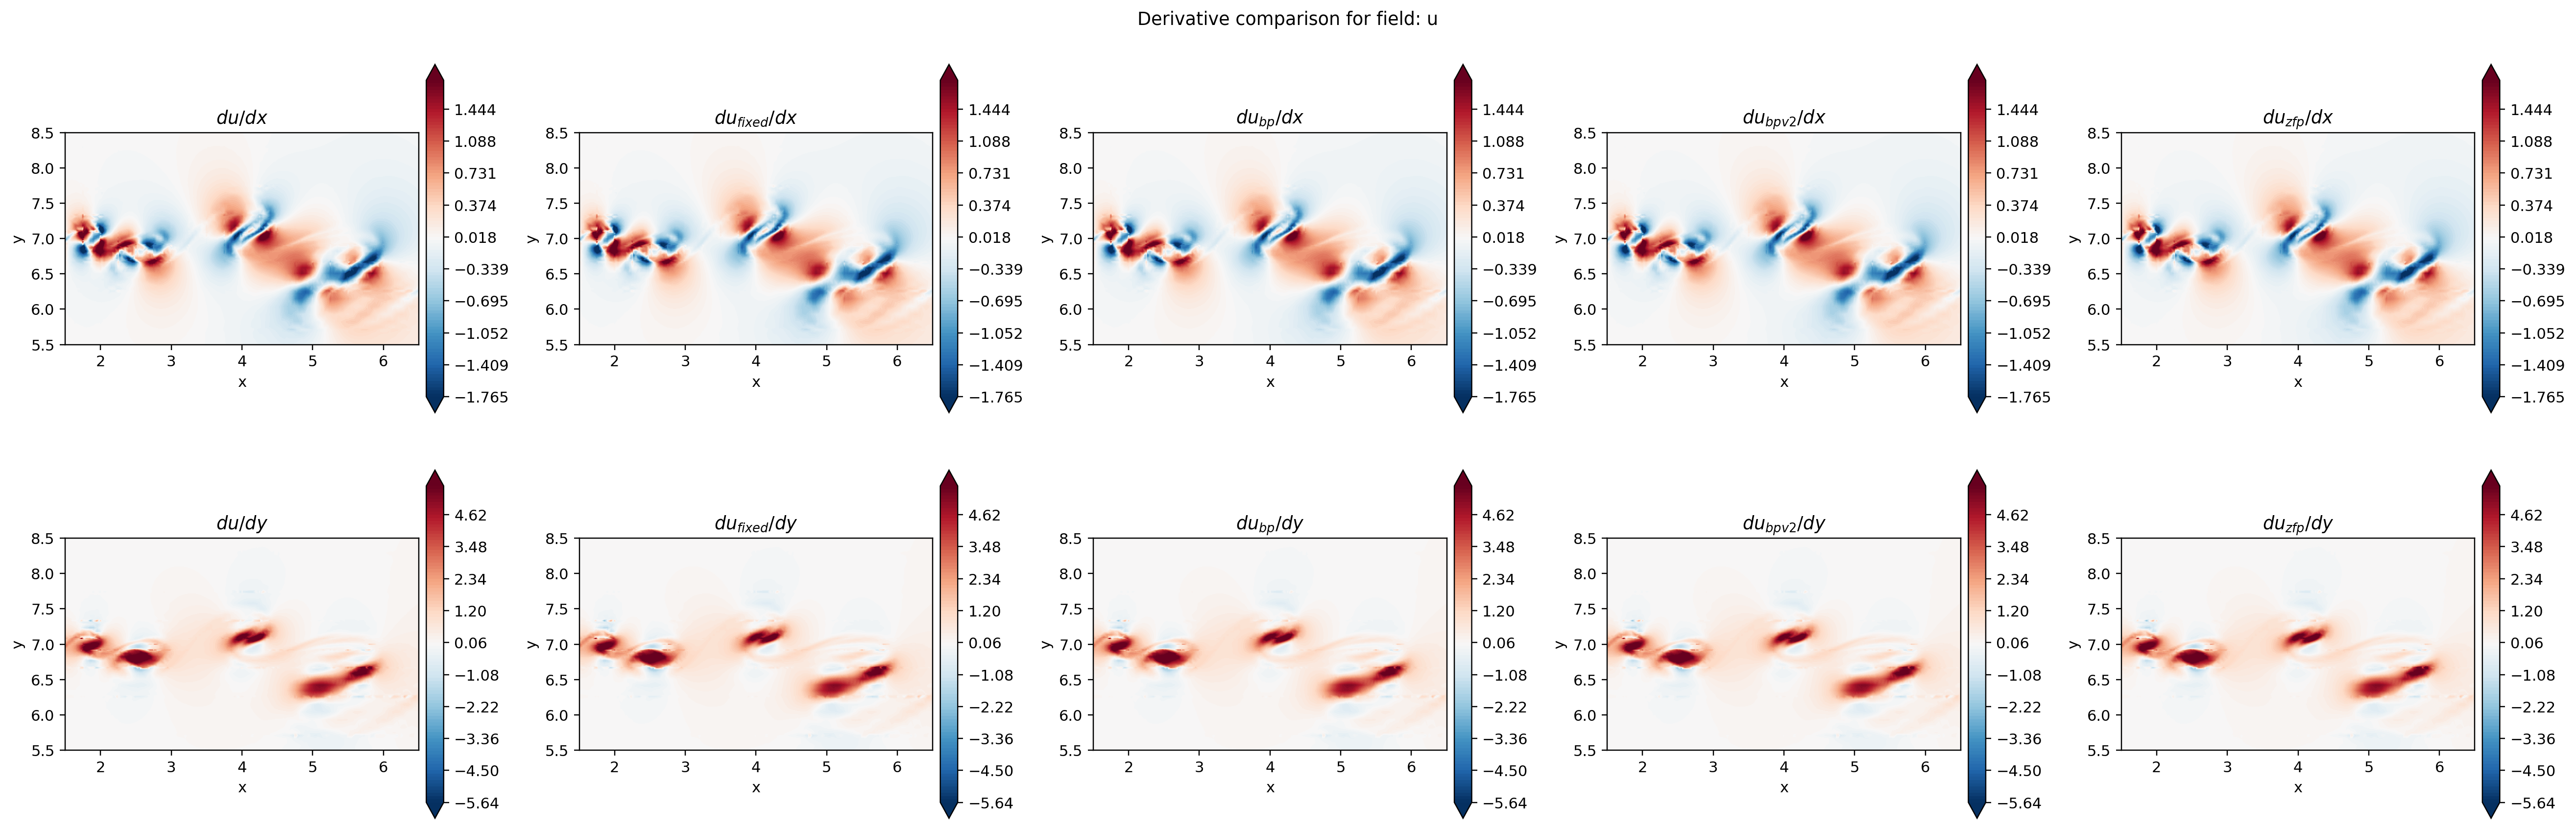

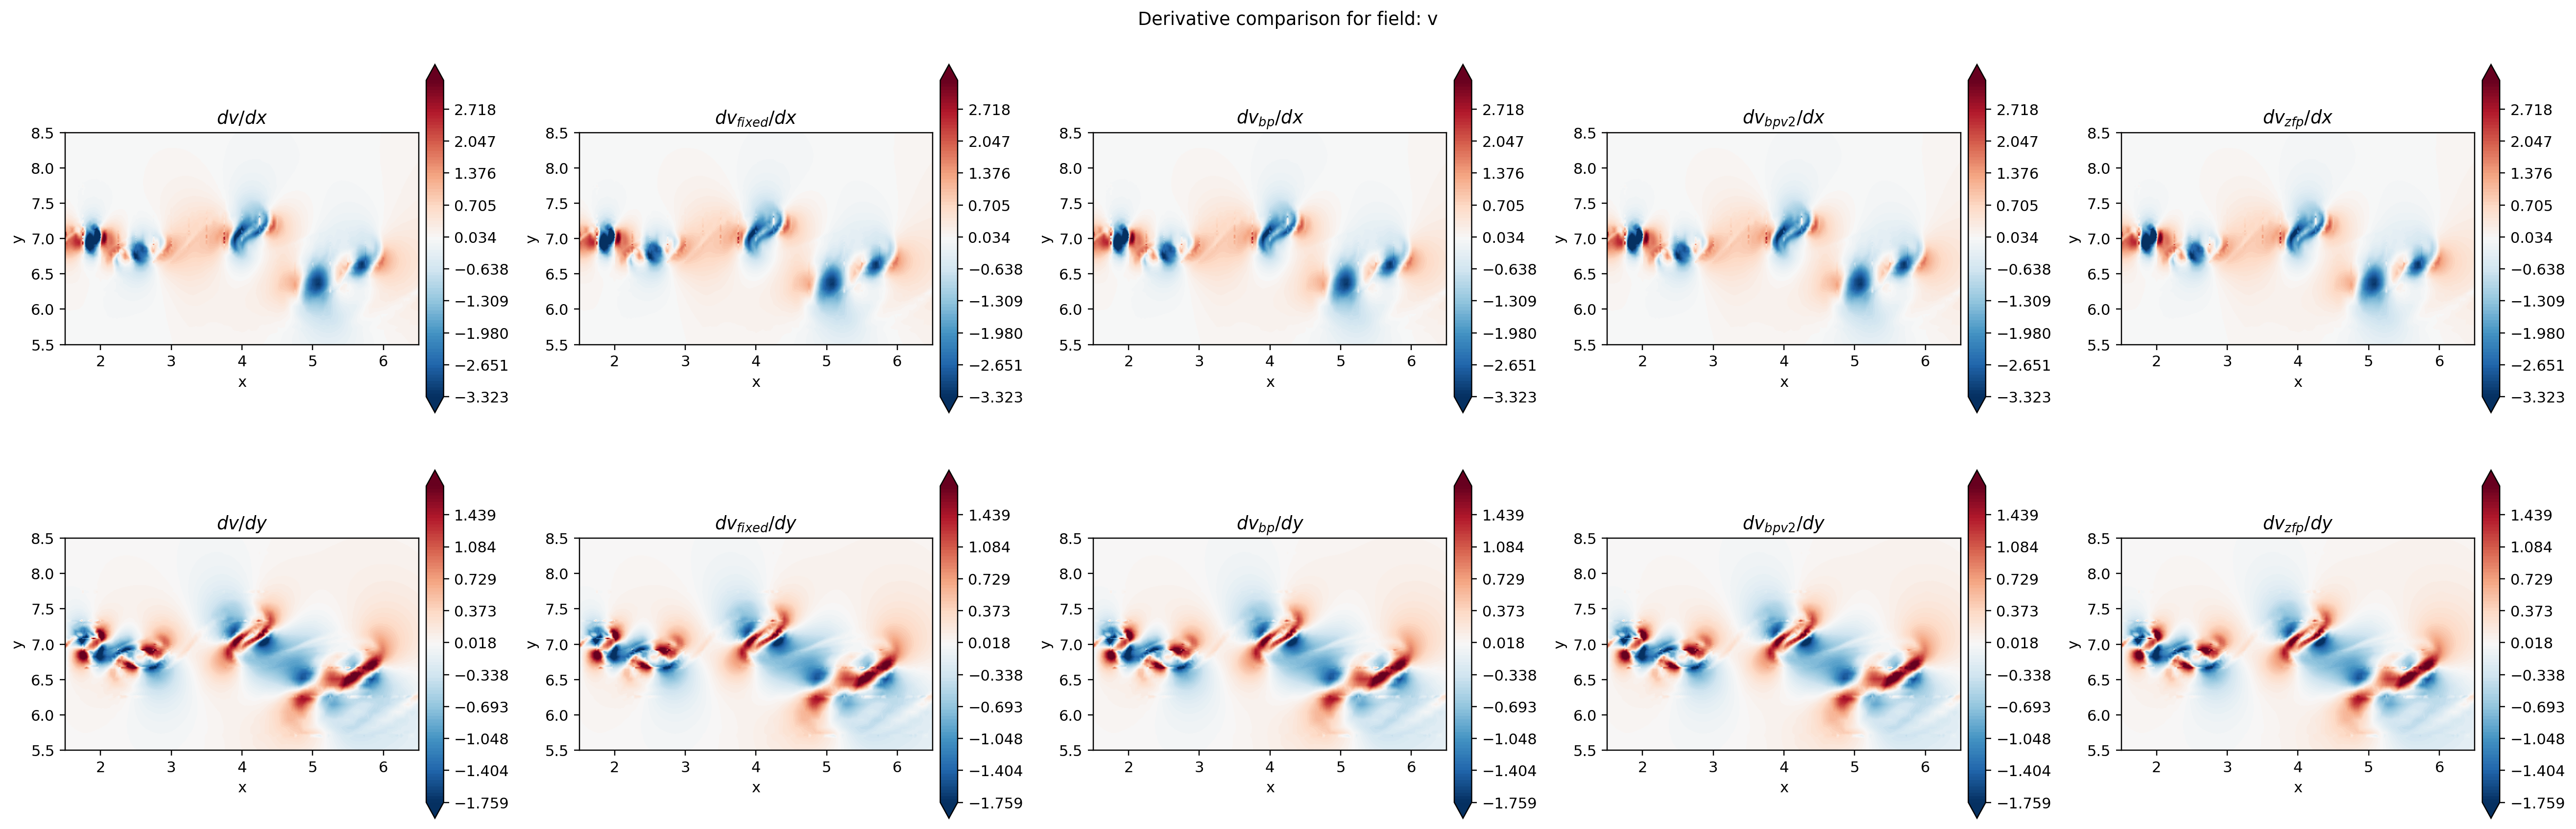

In [13]:
if 1 == 1:

    # Zoom window where visibility matters most.
    xlim_zoom = (1.5, 6.5)
    ylim_zoom = (5.5, 8.5)

    x_flat = msh.x.flatten()
    y_flat = msh.y.flatten()
    zoom_mask = (
        (x_flat >= xlim_zoom[0])
        & (x_flat <= xlim_zoom[1])
        & (y_flat >= ylim_zoom[0])
        & (y_flat <= ylim_zoom[1])
    )

    def _visible_levels(values_flat, n_levels=100):
        local_vals = values_flat[zoom_mask] if np.any(zoom_mask) else values_flat
        local_vals = local_vals[np.isfinite(local_vals)]

        if local_vals.size == 0:
            return np.linspace(-1.0, 1.0, n_levels)

        vmin, vmax = np.percentile(local_vals, [1, 99])

        # Keep diverging maps balanced around zero when signs are mixed.
        if vmin < 0.0 < vmax:
            vmax_abs = max(abs(vmin), abs(vmax))
            vmin, vmax = -vmax_abs, vmax_abs

        if np.isclose(vmin, vmax):
            eps = max(abs(vmax), 1.0) * 1e-6
            vmin -= eps
            vmax += eps

        return np.linspace(vmin, vmax, n_levels)

    for fld_name in plot_fields:
        fig, ax = plt.subplots(ncols=5, nrows=2, figsize=(24, 8), dpi=220)

        # Prepare flattened arrays once.
        dudx_ref = dudx[fld_name].flatten()
        dudx_fix = dudx_np[fld_name].flatten()
        dudx_bp1 = dudx_bp[fld_name].flatten()
        dudx_bp2 = dudx_bp_v2[fld_name].flatten()
        dudx_z = dudx_zfp[fld_name].flatten()

        dudy_ref = dudy[fld_name].flatten()
        dudy_fix = dudy_np[fld_name].flatten()
        dudy_bp1 = dudy_bp[fld_name].flatten()
        dudy_bp2 = dudy_bp_v2[fld_name].flatten()
        dudy_z = dudy_zfp[fld_name].flatten()

        # Use the reference derivative as the shared color range in each row.
        levels_dx = _visible_levels(dudx_ref)
        levels_dy = _visible_levels(dudy_ref)

        # du/dx
        c00 = ax[0,0].tricontourf(x_flat, y_flat, dudx_ref, levels=levels_dx, cmap="RdBu_r", extend="both")
        ax[0,0].set_aspect('equal')
        ax[0,0].set_xlabel("x")
        ax[0,0].set_ylabel("y")
        ax[0,0].set_title(rf"$d{fld_name}/dx$")

        c01 = ax[0,1].tricontourf(x_flat, y_flat, dudx_fix, levels=levels_dx, cmap="RdBu_r", extend="both")
        ax[0,1].set_aspect('equal')
        ax[0,1].set_xlabel("x")
        ax[0,1].set_ylabel("y")
        ax[0,1].set_title(rf"$d{fld_name}_{{fixed}}/dx$")

        c02 = ax[0,2].tricontourf(x_flat, y_flat, dudx_bp1, levels=levels_dx, cmap="RdBu_r", extend="both")
        ax[0,2].set_aspect('equal')
        ax[0,2].set_xlabel("x")
        ax[0,2].set_ylabel("y")
        ax[0,2].set_title(rf"$d{fld_name}_{{bp}}/dx$")

        c03 = ax[0,3].tricontourf(x_flat, y_flat, dudx_bp2, levels=levels_dx, cmap="RdBu_r", extend="both")
        ax[0,3].set_aspect('equal')
        ax[0,3].set_xlabel("x")
        ax[0,3].set_ylabel("y")
        ax[0,3].set_title(rf"$d{fld_name}_{{bpv2}}/dx$")

        c04 = ax[0,4].tricontourf(x_flat, y_flat, dudx_z, levels=levels_dx, cmap="RdBu_r", extend="both")
        ax[0,4].set_aspect('equal')
        ax[0,4].set_xlabel("x")
        ax[0,4].set_ylabel("y")
        ax[0,4].set_title(rf"$d{fld_name}_{{zfp}}/dx$")

        # du/dy
        c10 = ax[1,0].tricontourf(x_flat, y_flat, dudy_ref, levels=levels_dy, cmap="RdBu_r", extend="both")
        ax[1,0].set_aspect('equal')
        ax[1,0].set_xlabel("x")
        ax[1,0].set_ylabel("y")
        ax[1,0].set_title(rf"$d{fld_name}/dy$")

        c11 = ax[1,1].tricontourf(x_flat, y_flat, dudy_fix, levels=levels_dy, cmap="RdBu_r", extend="both")
        ax[1,1].set_aspect('equal')
        ax[1,1].set_xlabel("x")
        ax[1,1].set_ylabel("y")
        ax[1,1].set_title(rf"$d{fld_name}_{{fixed}}/dy$")

        c12 = ax[1,2].tricontourf(x_flat, y_flat, dudy_bp1, levels=levels_dy, cmap="RdBu_r", extend="both")
        ax[1,2].set_aspect('equal')
        ax[1,2].set_xlabel("x")
        ax[1,2].set_ylabel("y")
        ax[1,2].set_title(rf"$d{fld_name}_{{bp}}/dy$")

        c13 = ax[1,3].tricontourf(x_flat, y_flat, dudy_bp2, levels=levels_dy, cmap="RdBu_r", extend="both")
        ax[1,3].set_aspect('equal')
        ax[1,3].set_xlabel("x")
        ax[1,3].set_ylabel("y")
        ax[1,3].set_title(rf"$d{fld_name}_{{bpv2}}/dy$")

        c14 = ax[1,4].tricontourf(x_flat, y_flat, dudy_z, levels=levels_dy, cmap="RdBu_r", extend="both")
        ax[1,4].set_aspect('equal')
        ax[1,4].set_xlabel("x")
        ax[1,4].set_ylabel("y")
        ax[1,4].set_title(rf"$d{fld_name}_{{zfp}}/dy$")

        # One colorbar per panel, all tied to the reference row scale.
        fig.colorbar(c00, ax=ax[0,0], fraction=0.046, pad=0.02)
        fig.colorbar(c01, ax=ax[0,1], fraction=0.046, pad=0.02)
        fig.colorbar(c02, ax=ax[0,2], fraction=0.046, pad=0.02)
        fig.colorbar(c03, ax=ax[0,3], fraction=0.046, pad=0.02)
        fig.colorbar(c04, ax=ax[0,4], fraction=0.046, pad=0.02)
        fig.colorbar(c10, ax=ax[1,0], fraction=0.046, pad=0.02)
        fig.colorbar(c11, ax=ax[1,1], fraction=0.046, pad=0.02)
        fig.colorbar(c12, ax=ax[1,2], fraction=0.046, pad=0.02)
        fig.colorbar(c13, ax=ax[1,3], fraction=0.046, pad=0.02)
        fig.colorbar(c14, ax=ax[1,4], fraction=0.046, pad=0.02)

        for i in range(5):
            ax[0,i].set_xlim(list(xlim_zoom))
            ax[0,i].set_ylim(list(ylim_zoom))
            ax[1,i].set_xlim(list(xlim_zoom))
            ax[1,i].set_ylim(list(ylim_zoom))

        fig.suptitle(f"Derivative comparison for field: {fld_name}")
        plt.tight_layout()
        plt.show()

## Metrics

Check reconstruction error against the fixed-error target.

In [14]:
# B-weighted physical-space reconstruction error per field + tabular reporting.
def _format_bytes(nbytes):
    units = ["B", "KB", "MB", "GB", "TB"]
    value = float(nbytes)
    for unit in units:
        if value < 1024.0 or unit == units[-1]:
            return f"{value:.2f} {unit}"
        value /= 1024.0

def _size_bytes_using_existing(path):
    # Reuse the existing notebook helper when possible.
    if os.path.isfile(path):
        return os.path.getsize(path)
    return get_folder_size(path)

def _print_ascii_table(headers, rows):
    str_rows = [[str(v) for v in row] for row in rows]
    widths = [len(str(h)) for h in headers]
    for row in str_rows:
        for i, value in enumerate(row):
            widths[i] = max(widths[i], len(value))

    def _fmt_row(values):
        return "| " + " | ".join(str(values[i]).ljust(widths[i]) for i in range(len(values))) + " |"

    sep = "+-" + "-+-".join("-" * w for w in widths) + "-+"
    print(sep)
    print(_fmt_row(headers))
    print(sep)
    for row in str_rows:
        print(_fmt_row(row))
    print(sep)

B = coef.B
den_B = np.sum(B, axis=(1, 2, 3))
metrics_by_field = {}

for fld_name in plot_fields:
    u = fld.registry[fld_name]

    err_fixed = u_np[fld_name] - u
    err_bp = u_bp[fld_name] - u
    err_bp_v2 = u_bp_v2[fld_name] - u
    err_zfp = u_zfp[fld_name] - u

    rms_fixed = np.mean(np.sqrt(np.sum((err_fixed**2) * B, axis=(1, 2, 3)) / den_B))
    rms_bp = np.mean(np.sqrt(np.sum((err_bp**2) * B, axis=(1, 2, 3)) / den_B))
    rms_bp_v2 = np.mean(np.sqrt(np.sum((err_bp_v2**2) * B, axis=(1, 2, 3)) / den_B))
    rms_zfp = np.mean(np.sqrt(np.sum((err_zfp**2) * B, axis=(1, 2, 3)) / den_B))

    metrics_by_field[fld_name] = {
        "fixed_error": rms_fixed,
        "bitplane": rms_bp,
        "bitplane_v2": rms_bp_v2,
        "zfp": rms_zfp,
    }

print("\n=== Reconstruction Error by Method (mean B-weighted RMS) ===")
for method in ["fixed_error", "bitplane", "bitplane_v2", "zfp"]:
    print(f"\n--- {method} ---")
    rows = [[fld_name, f"{metrics_by_field[fld_name][method]:.3e}"] for fld_name in plot_fields]
    _print_ascii_table(["field", "error"], rows)

# File-size comparison: base vs compressed datasets.
num_values = int(sum(fld.registry[fld_name].size for fld_name in plot_fields))
base_path = "test_no_mesh"
compressed_paths = {
    "fixed_error": "test_comp",
    "bitplane": "test_bp_comp",
    "bitplane_v2": "test_bp_v2_comp",
    "zfp": "test_zfp_comp",
}

base_size = _size_bytes_using_existing(base_path)

print("\n=== Size Summary ===")
print(f"base ({base_path}): {base_size} bytes ({_format_bytes(base_size)})")
print(f"total doubles in all fields: {num_values}")

size_rows = []
for method, comp_path in compressed_paths.items():
    comp_size = _size_bytes_using_existing(comp_path)
    ratio_base_over_comp = (base_size / comp_size) if comp_size > 0 else np.nan
    ratio_comp_over_base = (comp_size / base_size) if base_size > 0 else np.nan
    bits_per_double = comp_size / base_size * 32 if base_size > 0 else np.nan

    ratio_boc_txt = f"{ratio_base_over_comp:.3f}x" if np.isfinite(ratio_base_over_comp) else "n/a"
    ratio_cob_txt = f"{ratio_comp_over_base:.3f}x" if np.isfinite(ratio_comp_over_base) else "n/a"
    bpd_txt = f"{bits_per_double:.3f}" if np.isfinite(bits_per_double) else "n/a"

    size_rows.append([
        method,
        f"{comp_size}",
        _format_bytes(comp_size),
        ratio_boc_txt,
        ratio_cob_txt,
        bpd_txt,
    ])

_print_ascii_table(
    [
        "method",
        "compressed bytes",
        "compressed size",
        "ratio (base/comp)",
        "ratio (comp/base)",
        "bits/double",
    ],
    size_rows,
 )


=== Reconstruction Error by Method (mean B-weighted RMS) ===

--- fixed_error ---
+-------+-----------+
| field | error     |
+-------+-----------+
| u     | 8.210e-07 |
| v     | 8.090e-07 |
+-------+-----------+

--- bitplane ---
+-------+-----------+
| field | error     |
+-------+-----------+
| u     | 7.044e-07 |
| v     | 7.027e-07 |
+-------+-----------+

--- bitplane_v2 ---
+-------+-----------+
| field | error     |
+-------+-----------+
| u     | 9.472e-07 |
| v     | 9.494e-07 |
+-------+-----------+

--- zfp ---
+-------+-----------+
| field | error     |
+-------+-----------+
| u     | 8.957e-07 |
| v     | 8.010e-07 |
+-------+-----------+

=== Size Summary ===
base (test_no_mesh): 2464136 bytes (2.35 MB)
total doubles in all fields: 204800
+-------------+------------------+-----------------+-------------------+-------------------+-------------+
| method      | compressed bytes | compressed size | ratio (base/comp) | ratio (comp/base) | bits/double |
+-------------+-----